### 0. Setup

In [1]:
#@title Downloads

!pip install -q --upgrade tqdm
!pip install midvoxio
!pip install onnx onnxscript onnxruntime
!pip install -U onnxruntime
!pip install lpips
!pip install onnx
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 132.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 47.7 MB/s eta 0:00:00


In [2]:
#@title Libraries
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from midvoxio.voxio import vox_to_arr
from midvoxio.voxio import viz_vox
from midvoxio.voxio import write_list_to_vox
from midvoxio.voxio import plot_3d
from mpl_toolkits.mplot3d import Axes3D
from google.colab import drive
import scipy
import torch.optim as optim
import random
from tqdm import tqdm
import lpips
import onnx
import onnxscript
import json
from pathlib import Path
import psutil
import trimesh
from google.colab import drive
drive.mount('/content/drive')
from google.colab import runtime
import os
import time
import struct

# Added for sweep
import seaborn as sns
import pandas as pd
import gc
from IPython.display import clear_output

Mounted at /content/drive


In [3]:
#@title Download/External links
!wget -O Regular_tree.vox "https://voxbox.store/api/model/download?id=8ryE8w3LOy"
!wget -O Fall_tree.vox "https://voxbox.store/api/model/download?id=rC2Fnv8YI2"
!wget -O Chicken.vox "https://voxbox.store/api/model/download?id=nTqJDfvpU9"
!wget -O Pine_tree.vox "https://voxbox.store/api/model/download?id=XHxA65ZDGj"
!wget -O Furnace.vox "https://voxbox.store/api/model/download?id=ei6SEQJPSs"
!wget -O Mug.vox "https://voxbox.store/api/model/download?id=d4cA4CJFYp"
!wget -O Mushroom.vox "https://voxbox.store/api/model/download?id=ky7oAEUGsh"
!wget -O Globe.vox "https://voxbox.store/api/model/download?id=05PJncdAqK"
!wget -O Willow_tree.vox "https://voxbox.store/api/model/download?id=F5onQ3PrXR"
!wget -O Fish.vox "https://voxbox.store/api/model/download?id=skHHkQHxOo"
!wget -O Winter_tree.vox "https://voxbox.store/api/model/download?id=PLdjQkdPRY"
!wget -O Mammoth.vox "https://voxbox.store/api/model/download?id=fhs7808ysc"

--2026-06-02 23:27:51--  https://voxbox.store/api/model/download?id=8ryE8w3LOy
Resolving voxbox.store (voxbox.store)... 5.161.231.181, 2a01:4ff:f0:8ec9::1
Connecting to voxbox.store (voxbox.store)|5.161.231.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1740611 (1.7M) [application/x-authorware-bin]
Saving to: ‘Regular_tree.vox’

Regular_tree.vox    100%[===================>]   1.66M  1.39MB/s    in 1.2s    

2026-06-02 23:27:54 (1.39 MB/s) - ‘Regular_tree.vox’ saved [1740611/1740611]

--2026-06-02 23:27:54--  https://voxbox.store/api/model/download?id=rC2Fnv8YI2
Resolving voxbox.store (voxbox.store)... 5.161.231.181, 2a01:4ff:f0:8ec9::1
Connecting to voxbox.store (voxbox.store)|5.161.231.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1740505 (1.7M) [application/x-authorware-bin]
Saving to: ‘Fall_tree.vox’

Fall_tree.vox       100%[===================>]   1.66M  1.37MB/s    in 1.2s    

2026-06-02 23:27:57 (1.37 MB/s) - ‘Fall

In [4]:
import struct
import numpy as np # Import numpy
import re # Import re for regex
from pathlib import Path # Import Path for easier filename manipulation

#@title Turn to Voxel

def raw_to_npy(input_path: str, output_path: str, channels_per_voxel: int = 4):
    """
    Converts a raw voxel file to a .npy file, extracting dimensions from the filename.

    Args:
        input_path (str): Path to the input .raw file. Expected format: 'filename_WxHxL_description.raw'.
        output_path (str): Path to save the output .npy file.
        channels_per_voxel (int): Number of channels per voxel in the raw file (1 for grayscale/alpha, 4 for RGBA).
    """
    file_name = Path(input_path).name
    match = re.search(r'_(\d+)x(\d+)x(\d+)_', file_name)

    if not match:
        raise ValueError(f"Could not extract dimensions (WxHxL) from filename: {file_name}. Expected format like '_WxHxL_'.")

    width = int(match.group(1))
    height = int(match.group(2))
    length = int(match.group(3))

    print(f"Detected dimensions: W={width}, H={height}, L={length}")
    print(f"Converting {input_path} to {output_path} (expected channels: {channels_per_voxel})...")
    try:
        with open(input_path, 'rb') as f:
            raw_bytes = f.read()

        expected_size = width * height * length * channels_per_voxel
        if len(raw_bytes) != expected_size:
            raise ValueError(f"Raw file size mismatch. Expected {expected_size} bytes ({width}x{height}x{length}x{channels_per_voxel}), got {len(raw_bytes)}.")

        flat_data = struct.unpack(f'{width * height * length * channels_per_voxel}B', raw_bytes)
        arr = np.array(flat_data, dtype=np.float32).reshape(length, height, width, channels_per_voxel) / 255.0

        if channels_per_voxel == 1:
            # If it's a single channel, treat it as alpha and make RGB white
            rgba_arr = np.ones((length, height, width, 4), dtype=np.float32)
            rgba_arr[..., 3] = arr[..., 0] # Assign the single channel to alpha
            arr = rgba_arr

        np.save(output_path, arr)
        print(f"Successfully converted and saved to {output_path}")

    except FileNotFoundError:
        print(f"Error: Input file not found at {input_path}")
    except ValueError as e:
        print(f"Error processing raw file: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Updated call to raw_to_npy assuming single channel raw file and dimensions from filename
raw_to_npy('tooth_103x94x161_uint8.raw', 'tooth.npy', channels_per_voxel=1)

Detected dimensions: W=103, H=94, L=161
Converting tooth_103x94x161_uint8.raw to tooth.npy (expected channels: 1)...
Error: Input file not found at tooth_103x94x161_uint8.raw


In [5]:
#@title Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found — training will be slow.")
    print("    Runtime → Change runtime type → T4 GPU")

Device : cuda
GPU    : NVIDIA A100-SXM4-80GB


In [6]:
VOX_FILES = [
    'Regular_tree.vox',
    'Fall_tree.vox',
    'Chicken.vox',
    'Pine_tree.vox',
    'Furnace.vox',
    'Mug.vox',
    'Mushroom.vox',
    'Globe.vox',
    'Willow_tree.vox',
    'Fish.vox',
    'Winter_tree.vox',
    'Mammoth.vox',
    'Big_mario.npy',
    # 'tooth.npy'
]

for vox_path in VOX_FILES:
    if vox_path.endswith('.npy'):
        raw_data = np.load(vox_path)
        if raw_data.ndim == 2 and raw_data.shape[1] >= 6:
            # Reconstruct dense grid from [x, y, z, r, g, b]
            coords = raw_data[:, :3].astype(int)
            colors = raw_data[:, 3:6].astype(np.float32)
            if colors.max() > 1.0: colors /= 255.0

            d_max, h_max, w_max = coords.max(axis=0) + 1
            arr = np.zeros((d_max, h_max, w_max, 4), dtype=np.float32)
            arr[coords[:, 0], coords[:, 1], coords[:, 2], :3] = colors
            arr[coords[:, 0], coords[:, 1], coords[:, 2], 3] = 1.0
        else:
            arr = raw_data
            if arr.max() > 1.0: arr = arr.astype(np.float32) / 255.0
    else:
        arr = vox_to_arr(vox_path, -1)
    print(f'{vox_path}: {arr.shape}')

_t in nTRN not match models, transform not applied
Regular_tree.vox: (256, 256, 256, 4)
Fall_tree.vox: (256, 256, 256, 4)
Chicken.vox: (11, 5, 10, 4)
Pine_tree.vox: (128, 128, 128, 4)
_t in nTRN not match models, transform not applied
Furnace.vox: (16, 16, 16, 4)
Mug.vox: (36, 36, 19, 4)
Mushroom.vox: (70, 71, 75, 4)
Globe.vox: (68, 68, 68, 4)
Willow_tree.vox: (256, 256, 256, 4)
Fish.vox: (76, 83, 75, 4)
Winter_tree.vox: (256, 256, 259, 4)
Mammoth.vox: (73, 120, 95, 4)
Big_mario.npy: (64, 64, 64, 4)


### 1. Perception

In [7]:
class Perception(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.perceive = nn.Conv3d(
            channels,
            channels * 4,       # identity + sobel_x + sobel_y + sobel_z
            kernel_size=3,
            padding=1,
            groups=channels,
            bias=False
        )

        a = torch.tensor([1, 2, 1], dtype=torch.float32)
        b = torch.tensor([-1, 0, 1], dtype=torch.float32)

        sobel_x = torch.einsum('i,j,k->ijk', a, a, b)
        sobel_y = torch.einsum('i,j,k->ijk', a, b, a)
        sobel_z = torch.einsum('i,j,k->ijk', b, a, a)

        identity = torch.zeros(3, 3, 3, dtype=torch.float32)
        identity[1, 1, 1] = 1.0

        kernels = torch.stack([identity, sobel_x, sobel_y, sobel_z], dim=0)
        kernels = kernels.unsqueeze(1)
        kernels = kernels.repeat(channels, 1, 1, 1, 1)

        with torch.no_grad():
            self.perceive.weight.copy_(kernels)

        self.n_channels = channels

    def forward(self, x):
        return self.perceive(x)

### 2. Adaptation

In [8]:
class Adaptation(nn.Module):
    def __init__(self, channels, hidden_channels=256):
        super().__init__()
        self.adapt = nn.Sequential(
            nn.Conv3d(channels * 4, hidden_channels, kernel_size=1),  # 4x now
            nn.ReLU(),
            nn.Conv3d(hidden_channels, channels, kernel_size=1, bias=False)
        )
        nn.init.zeros_(self.adapt[-1].weight)

    def forward(self, x):
        return self.adapt(x)

### 3. LPPN

In [9]:
#@title Sine layer
class SineLayer(nn.Module):
    # SIREN-style sine activation layer [cite: 155, 156]
    def __init__(self, in_features, out_features, is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.linear.in_features, 1 / self.linear.in_features)
            else:
                self.linear.weight.uniform_(
                    -np.sqrt(6 / self.linear.in_features) / self.omega_0,
                    np.sqrt(6 / self.linear.in_features) / self.omega_0
                )

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))

In [10]:

#@title LPPN
class LPPN(nn.Module):
    def __init__(self, nca_channels, out_channels=4, hidden_dim=64, harmonics=1, num_sine_layers=4):
        super().__init__()
        # u-coordinates for a cube primitive are Cartesian[cite: 92].
        # We encode them with a sinusoidal basis of the first n harmonics[cite: 107].
        # 3 coords (x,y,z) * 2 (sin, cos) * harmonics
        coord_dim = 3 * 2 * harmonics
        in_dim = nca_channels + coord_dim

        self.harmonics = harmonics

        layers = [SineLayer(in_dim, hidden_dim, is_first=True)]
        for _ in range(max(0, num_sine_layers - 1)):
            layers.append(SineLayer(hidden_dim, hidden_dim))
        layers.append(nn.Linear(hidden_dim, out_channels))
        self.net = nn.Sequential(*layers)

    def encode_coordinates(self, u):
        # u is [..., 3] inside [-1, 1] [cite: 95]
        features = []
        for n in range(1, self.harmonics + 1):
            features.append(torch.sin(np.pi * n * u))
            features.append(torch.cos(np.pi * n * u))
        return torch.cat(features, dim=-1)

    def forward(self, state, u):
        # state: [B, C, D, H, W], u: [B, 3, D, H, W]
        # Rearrange to sequence for MLP processing
        B, C, D, H, W = state.shape

        state = state.permute(0, 2, 3, 4, 1).reshape(-1, C)
        u = u.permute(0, 2, 3, 4, 1).reshape(-1, 3)

        u_encoded = self.encode_coordinates(u)

        x = torch.cat([state, u_encoded], dim=-1)
        out = self.net(x)

        # Reshape back to grid: [B, Out_C, D, H, W]
        out = out.view(B, D, H, W, -1).permute(0, 4, 1, 2, 3)
        return out

### 4. NCA

In [20]:
class NCA(nn.Module):
    def __init__(self, channels=16, coarse_size=32, dt=1.0, p_update=0.5, lppn_hidden=64, harmonics=1, num_sine_layers=4):
        super().__init__()
        self.channels = channels
        self.dt = dt
        self.p_update = p_update
        self.coarse_size = coarse_size
        self.iterations = 0

        self.perception = Perception(channels)
        self.adaptation = Adaptation(channels)
        self.lppn = LPPN(channels, out_channels=4, hidden_dim=lppn_hidden, harmonics=harmonics, num_sine_layers=num_sine_layers)

        self.target_size = None
        self.scale = None

    def step(self, x):
        pre_life_mask = self.get_living_mask(x)

        z = self.perception(x)
        dx = self.adaptation(z)

        update_mask = (torch.rand(x[:, :1, ...].shape, device=x.device) < self.p_update).float()
        x = x + self.dt * dx * update_mask
        x = torch.clamp(x, -1.0, 1.0)
        post_life_mask = self.get_living_mask(x)
        life_mask = pre_life_mask & post_life_mask
        return x * life_mask.float()

    def get_living_mask(self, x, threshold=0.1):
        alpha = x[:, 0:1]
        return F.max_pool3d(alpha, kernel_size=3, stride=1, padding=1) > threshold

    def forward(self, x, steps):
        for _ in range(steps):
            x = self.step(x)
        return x

    def create_seed(self, batch_size, device='cuda'):
        depth = height = width = self.coarse_size
        seed = torch.zeros(batch_size, self.channels, depth, height, width, device=device)
        cd, ch, cw = depth // 2, height // 2, width // 2
        seed[:, 0, cd, ch, cw] = 1.0
        return seed

    def apply_output_activation(self, prediction):
        rgb = torch.sigmoid(prediction[:, :3, ...])
        alpha = torch.sigmoid(prediction[:, 3:4, ...])
        return torch.cat([rgb, alpha], dim=1)

    def display_voxels(self, voxel_grid, threshold=0.1, apply_activation=False):
        if voxel_grid.dim() == 4:
            voxel_grid = voxel_grid.unsqueeze(0)
        if apply_activation:
            voxel_grid = self.apply_output_activation(voxel_grid)

        # [C, D, H, W]
        voxel_grid = voxel_grid[0].detach().cpu().numpy()

        # Transpose to [D, H, W, C]
        voxel_grid = voxel_grid.transpose(1, 2, 3, 0)
        rgb = np.clip(voxel_grid[..., :3], 0, 1)
        alpha = np.clip(voxel_grid[..., 3], 0, 1)

        filled = alpha > threshold

        # Prepare color grid for ax.voxels
        colors = np.zeros(filled.shape + (4,))
        colors[..., :3] = rgb
        colors[..., 3] = alpha

        if not np.any(filled):
            print("No voxels to display.")
            return

        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.voxels(filled, facecolors=colors, edgecolor=None)

        max_dim = max(filled.shape)
        ax.set_xlim([0, max_dim])
        ax.set_ylim([0, max_dim])
        ax.set_zlim([0, max_dim])
        plt.show()

    def load(self, target_path, margin_proportion=0.25, display_plots=True):
        device = next(self.parameters()).device

        if target_path.endswith('.npy'):
            raw_data = np.load(target_path)
            if raw_data.ndim == 2 and raw_data.shape[1] >= 6:
                # Reconstruct dense grid from [x, y, z, r, g, b]
                coords = raw_data[:, :3].astype(int)
                colors = raw_data[:, 3:6].astype(np.float32)
                if colors.max() > 1.0: colors /= 255.0

                d_max, h_max, w_max = coords.max(axis=0) + 1
                obj = np.zeros((d_max, h_max, w_max, 4), dtype=np.float32)
                obj[coords[:, 0], coords[:, 1], coords[:, 2], :3] = colors
                obj[coords[:, 0], coords[:, 1], coords[:, 2], 3] = 1.0
            else:
                obj = raw_data
                if obj.max() > 1.0: obj = obj.astype(np.float32) / 255.0
        else:
            obj = vox_to_arr(target_path, -1)

        print(f"Loaded {target_path}: raw shape {obj.shape}") # Added print statement
        obj = torch.tensor(obj, dtype=torch.float32).permute(3, 0, 1, 2)
        _, d, h, w = obj.shape
        orig_max_size = max(d, h, w)

        margin = int(orig_max_size * margin_proportion)
        target_size = orig_max_size + 2 * margin

        pad_d0 = (target_size - d) // 2; pad_d1 = target_size - d - pad_d0
        pad_h0 = (target_size - h) // 2; pad_h1 = target_size - h - pad_h0
        pad_w0 = (target_size - w) // 2; pad_w1 = target_size - w - pad_w0
        obj = F.pad(obj, (pad_w0, pad_w1, pad_h0, pad_h1, pad_d0, pad_d1))

        # Dynamically pad the coarse size based on the margin proportion
        self.coarse_size = self.coarse_size + 2 * int(self.coarse_size * margin_proportion)

        if target_size < self.coarse_size:
            self.coarse_size = target_size

        self.target_rgba   = obj.to(device)
        self.target_coarse = F.interpolate(
            self.target_rgba.unsqueeze(0),
            size=(self.coarse_size,) * 3,
            mode='trilinear', align_corners=False
        ).squeeze(0)

        self.scale = target_size / self.coarse_size
        self.target_size  = target_size

        if display_plots:
            print(f"Visualizing Target from {target_path}...")
            self.display_voxels(self.target_rgba)
            print("Visualizing Coarse Target...")
            self.display_voxels(self.target_coarse)

In [21]:
#@title Loss and train
def _compute_morphology_loss(self, state):
    B, C, D, H, W = state.shape

    # 1. Trilinear interpolation of the coarse NCA state [cite: 316]
    state_interpolated = F.interpolate(state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)

    # 2. Generate Cartesian u-coordinates for the upsampled grid [cite: 191]
    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
    grid_z, grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, d_fine, device=state.device),
        torch.linspace(-1, 1, h_fine, device=state.device),
        torch.linspace(-1, 1, w_fine, device=state.device),
        indexing='ij'
    )
    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)

    # 3. Decode NCA state to high-resolution output via LPPN [cite: 255]
    predicted_hr_raw = self.lppn(state_interpolated, u_coords)
    predicted_hr = self.apply_output_activation(predicted_hr_raw)

    # Extract alphas
    target_hr = self.target_rgba
    if target_hr.dim() == 4:
        target_hr = target_hr.unsqueeze(0) # Converts [C, D, H, W] to [1, C, D, H, W]

    # Explicitly expand the target to match the current Batch size (B)
    target_hr = target_hr.expand(B, -1, -1, -1, -1)

    # Extract alphas
    pred_alpha = predicted_hr[:, 3:4, ...]
    target_alpha = target_hr[:, 3:4, ...]

    # 4. (i) RGBA reconstruction on LPPN output (Masked) [cite: 257]
    # The paper applies l1+l2 after masking both outputs by their alpha channels.
    pred_masked = predicted_hr * pred_alpha
    target_masked = target_hr * target_alpha

    rgba_loss = F.l1_loss(pred_masked, target_masked) + F.mse_loss(pred_masked, target_masked)

    # 5. (ii) Shape loss on the NCA living mask [cite: 258, 259]
    # Upsample the coarse living mask (channel 0) to render resolution and supervise against target alpha.
    living_mask_coarse = state[:, 0:1, ...]
    living_mask_up = F.interpolate(living_mask_coarse, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)

    shape_loss = F.l1_loss(living_mask_up, target_alpha) + F.mse_loss(living_mask_up, target_alpha)

    # Unweighted sum of RGBA loss and shape loss [cite: 256]
    return rgba_loss + shape_loss, shape_loss, rgba_loss

def _nca_alone_loss(self, state):
    """
    Optional: Evaluates the coarse NCA state directly against a coarse target.
    Useful for warm-up or ablation testing, but not part of the final hybrid paper logic.
    """
    predicted_coarse_rgba = state[:, :4, ...]
    coarse_target_alpha = self.target_coarse[:, 3:4, ...]
    pred_alpha = predicted_coarse_rgba[:, 3:4, ...]

    # Applying the paper's alpha-masking logic to the coarse grid
    pred_masked = predicted_coarse_rgba * pred_alpha
    target_masked = self.target_coarse * coarse_target_alpha

    l1_loss = F.l1_loss(pred_masked, target_masked)
    l2_loss = F.mse_loss(pred_masked, target_masked)

    return l1_loss + l2_loss

def _training_step(self, optimizer, seed_state, steps):
    """
    Full end-to-end training step: runs the NCA, computes the paper's hybrid morphology loss,
    and backpropagates.
    """
    self.train()
    optimizer.zero_grad()

    # 1. Run NCA on the coarse lattice [cite: 255]
    final_state = self.forward(seed_state, steps)

    # 2. Compute end-to-end morphology loss on high-res LPPN output [cite: 256]
    total_loss, _, _ = self.compute_morphology_loss(final_state)

    total_loss.backward()

    # 3. Normalize gradients for NCA stability [cite: 277, 482]
    # Note: The paper explicitly states NOT to normalize LPPN gradients.
    torch.nn.utils.clip_grad_norm_(self.perception.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(self.adaptation.parameters(), 1.0)

    optimizer.step()

    return total_loss.item()

def _train_morphogenesis(self, iterations=1500, lr=1e-3, batch_size=4, step_range=(32, 96), pool_size=1024, viz_log=100, plot_log_interval=10):
        """
        Complete training loop with a Checkpoint Pool to prevent local minima.
        """

        from IPython import display
        from IPython.display import clear_output

        device = next(self.parameters()).device
        optimizer = optim.Adam(self.parameters(), lr=lr)

        # Slower decay to give the pool time to evolve
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.3)

        if self.coarse_size is None:
            raise ValueError("Model coarse_size is not set. Run self.load(...) first.")
        D, H, W = self.coarse_size, self.coarse_size, self.coarse_size

        print(f"Initializing checkpoint pool of size {pool_size}...")
        # Create the persistent pool of states
        pool = self.create_seed(batch_size=pool_size, device=device)

        print(f"Starting training on {device} for {iterations} iterations...")

        loss_history = []
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss')
        ax.set_title('Training Loss Over Time')
        line, = ax.plot([], [], 'b-') # Initialize an empty line for updates
        plt.grid(True)
        plt.tight_layout()
        display.display(fig) # Initial display of the empty plot
        plt.close(fig) # Close the static plot to avoid duplicates

        for i in range(1, iterations + 1):
            self.iterations += 1
            steps = random.randint(step_range[0], step_range[1])

            # --- POOL LOGIC START ---
            # 1. Sample a random batch of indices from the pool
            batch_indices = random.sample(range(pool_size), batch_size)
            current_state = pool[batch_indices].clone()

            # 2. Replace the first item in the batch with a fresh seed
            # This ensures the NCA never forgets how to start growing from step 0
            current_state[0] = self.create_seed(batch_size=1, device=device)[0]
            # --- POOL LOGIC END ---

            self.train()
            optimizer.zero_grad()

            # Forward pass
            final_state = self.forward(current_state, steps)
            loss, _, _ = self.compute_morphology_loss(final_state)

            # Overflow Regularizer (Crucial for pooled training stability)
            # Penalizes states that drift wildly outside the [-1, 1] range
            overflow_loss = torch.mean(torch.abs(final_state - torch.clamp(final_state, -1.0, 1.0)))
            total_loss = loss + (100.0 * overflow_loss)

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(self.perception.parameters(), 1.0)
            torch.nn.utils.clip_grad_norm_(self.adaptation.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

            # --- COMMIT TO POOL ---
            # Save the evolved states back into the pool for future iterations
            pool[batch_indices] = final_state.detach()

            # Logging and plotting
            loss_history.append(total_loss.item())
            if i % plot_log_interval == 0 or i == 1 or i == iterations:
                current_lr = scheduler.get_last_lr()[0]
                # Clear previous text output before printing new status and updating plot
                clear_output(wait=True)
                print(f"Iteration {i:04d} | Loss: {total_loss.item():.8f} | Steps: {steps} | LR: {current_lr:.6f}")

                line.set_xdata(range(1, i + 1))
                line.set_ydata(loss_history)
                ax.set_xlim(0, iterations)
                ax.set_ylim(0, max(loss_history) * 1.1 if loss_history else 1.0)
                # Redraw the canvas for the plot to update
                fig.canvas.draw()
                fig.canvas.flush_events()
                # Display the updated figure in Colab output
                display.display(fig)

            # Periodic Visualization (controlled by viz_log)
            if i % viz_log == 0 or i == iterations:
                print(f"--- Visualizing Output at Iteration {i} ---")
                with torch.no_grad():
                    test_seed = self.create_seed(batch_size=1, device=device)
                    test_final_state = self(test_seed, steps=64)

                    B, C, D_c, H_c, W_c = test_final_state.shape
                    state_interpolated = torch.nn.functional.interpolate(
                        test_final_state, size=(self.target_size,) * 3, mode='trilinear', align_corners=False
                    )

                    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
                    grid_z, grid_y, grid_x = torch.meshgrid(
                        torch.linspace(-1, 1, d_fine, device=device),
                        torch.linspace(-1, 1, h_fine, device=device),
                        torch.linspace(-1, 1, w_fine, device=device),
                        indexing='ij'
                    )
                    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)

                    decoded = self.lppn(state_interpolated, u_coords)
                    self.display_voxels(decoded[0], apply_activation=True)

def _test_seed_rollout(self, steps=64, render_size=None, display=True):
    device = next(self.parameters()).device
    with torch.no_grad():
        seed = self.create_seed(batch_size=1, device=device)
        final_state = self(seed, steps=steps)
        decoded = self.decode(final_state, render_size=render_size)

        result = {
            'seed': seed[0],
            'coarse_state': final_state[0],
            'decoded': decoded[0],
            'alive_cells': int((final_state[0, 0] > 0.1).sum().item()),
        }

        render_shape = tuple(decoded.shape[-3:])
        print(f"[SEED TEST] steps={steps} render_size={render_shape} alive_cells={result['alive_cells']}")

        if display:
            print('[SEED TEST] coarse living mask')
            coarse_preview = torch.zeros(4, *final_state.shape[2:], device=device)
            coarse_preview[3] = final_state[0, 0]
            self.display_voxels(coarse_preview)
            print('[SEED TEST] decoded output')
            self.display_voxels(decoded[0])

    return result

def _diagnose(self, steps=64):
    device = next(self.parameters()).device
    with torch.no_grad():
        seed = self.create_seed(batch_size=1, device=device)
        print(f"[SEED]  alive cells: {(seed[0,0]>0.1).sum().item()}")

        for s in [1, 4, 8, 16, 32, 64]:
            x = self(seed.clone(), steps=s)
            alive = (x[0,0] > 0.1).sum().item()
            ch0 = x[0,0]
            print(f"[NCA s={s:3d}]  alive: {alive:5d}  ch0 min:{ch0.min():.3f} max:{ch0.max():.3f} mean:{ch0.mean():.4f}")

        state_interp = F.interpolate(x, size=(self.target_size,) * 3, mode='trilinear', align_corners=False)
        print(f"\n[INTERP]  shape: {tuple(state_interp.shape)}  min:{state_interp.min():.3f} max:{state_interp.max():.3f}")

        d, h, w = state_interp.shape[2:]
        grid_z, grid_y, grid_x = torch.meshgrid(
            torch.linspace(-1, 1, d, device=device),
            torch.linspace(-1, 1, h, device=device),
            torch.linspace(-1, 1, w, device=device),
            indexing='ij'
        )
        u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0)
        decoded_raw = self.lppn(state_interp, u_coords)
        decoded = self.apply_output_activation(decoded_raw)

        print(f"\n[LPPN]  R  min:{decoded[0,0].min():.3f} max:{decoded[0,0].max():.3f}")
        print(f"[LPPN]  G  min:{decoded[0,1].min():.3f} max:{decoded[0,1].max():.3f}")
        print(f"[LPPN]  B  min:{decoded[0,2].min():.3f} max:{decoded[0,2].max():.3f}")
        print(f"[LPPN]  A  min:{decoded[0,3].min():.3f} max:{decoded[0,3].max():.3f} mean:{decoded[0,3].mean():.4f}")

        print(f"\n[TARGET] A  min:{self.target_rgba[3].min():.3f} max:{self.target_rgba[3].max():.3f} mean:{self.target_rgba[3].mean():.4f}")

NCA.test_seed_rollout = _test_seed_rollout
NCA.diagnose = _diagnose
NCA.training_step = _training_step
NCA.compute_morphology_loss = _compute_morphology_loss
NCA.nca_alone_loss = _nca_alone_loss
NCA.train_morphogenesis = _train_morphogenesis


In [22]:
NEWTON_COLOURS = np.array([
    [255, 0,   0,   255],  # red
    [255, 127, 0,   255],  # orange
    [255, 255, 0,   255],  # yellow
    [0,   255, 0,   255],  # green
    [0,   0,   255, 255],  # blue
    [75,  0,   130, 255],  # indigo
    [148, 0,   211, 255],  # violet
], dtype=np.uint8)

def generate_newton_sphere(radius: int, gap: int = 0, path: str = 'Newton_sphere.vox'):
    size = radius * 2 + 3
    center = size / 2.0 - 0.5
    shell_thickness = 1 + gap

    zz, yy, xx = np.mgrid[0:size, 0:size, 0:size]
    dist = np.sqrt((xx - center)**2 + (yy - center)**2 + (zz - center)**2)

    # float 0-1 grid for the vox array
    grid = np.zeros((size, size, size, 4), dtype=np.float32)

    for r in range(1, radius + 1):
        if gap > 0 and (r - 1) % shell_thickness != 0:
            continue
        band = (r - 1) // shell_thickness
        colour = NEWTON_COLOURS[band % len(NEWTON_COLOURS)] / 255.0
        if r == 1:
            mask = dist <= r  # fill the core completely
        else:
            mask = (dist <= r) & (dist > r - 1)
        grid[mask] = colour

    # palette as uint8 integers
    palette = np.zeros((256, 4), dtype=np.uint8)
    for i, colour in enumerate(NEWTON_COLOURS):
        palette[i + 1] = colour

    center_idx = size // 2
    print("center:  ", grid[center_idx, center_idx, center_idx])
    print("r=10:    ", grid[center_idx, center_idx, center_idx - 10])
    print("r=20:    ", grid[center_idx, center_idx, center_idx - 20])
    print("r=40:    ", grid[center_idx, center_idx, center_idx - 40])

    open(path, 'w').close()
    write_list_to_vox(grid, path, palette_arr=palette)
    print(f"Saved to {path}")

### 5. Instantiate & Inspect the Model

In [23]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_CHANNELS   = 40     # NCA hidden state channels
COARSE_SIZE  = 16     # NCA grid resolution
N_FREQS      = 1      # sinusoidal harmonics for local coords
LPPN_HIDDEN  = 72     # LPPN hidden width
LPPN_LAYERS  = 5      # LPPN depth
MARGIN_PROP  = 0.25   # Proportion of padding (0 to 1)

nca = NCA(
    channels         = N_CHANNELS,
    coarse_size      = COARSE_SIZE,
    lppn_hidden      = LPPN_HIDDEN,
    harmonics        = N_FREQS,
    num_sine_layers  = LPPN_LAYERS,
).to(DEVICE)

# Now supports loading .npy files directly
nca.load("Big_mario.npy", margin_proportion=MARGIN_PROP, display_plots=False)

# ── Parameter summary ────────────────────────────────────────────────────────
nca_params  = sum(p.numel() for p in nca.perception.parameters()) + \
              sum(p.numel() for p in nca.adaptation.parameters())
lppn_params = sum(p.numel() for p in nca.lppn.parameters())
total       = nca_params + lppn_params

print(f"{'─'*45}")
print(f"  Model summary")
print(f"{'─'*45}")
print(f"  NCA   (Perception + Adaptation) : {nca_params:>8,} params")
print(f"  LPPN  (SineNet + output head)   : {lppn_params:>8,} params")
print(f"  LPPN overhead                   : {lppn_params/nca_params*100:.1f} %")
print(f"  Total                           : {total:>8,} params")
print(f"{'─'*45}")
print(f"  Coarse grid  : {nca.coarse_size}×{nca.coarse_size}×{nca.coarse_size}")
print(f"  Render size  : {nca.target_size}×{nca.target_size}×{nca.target_size}")
print(f"  Device       : {DEVICE}")

def _decode(self, state, render_size=None):
    """Decode coarse NCA state to high-resolution RGBA via LPPN."""
    B = state.shape[0]
    if render_size is None:
        render_size = self.target_size
    if isinstance(render_size, int):
        render_size = (render_size, render_size, render_size)
    state_interpolated = F.interpolate(
        state, size=render_size, mode='trilinear', align_corners=False
    )
    d_fine, h_fine, w_fine = state_interpolated.shape[2:]
    grid_z, grid_y, grid_x = torch.meshgrid(
        torch.linspace(-1, 1, d_fine, device=state.device),
        torch.linspace(-1, 1, h_fine, device=state.device),
        torch.linspace(-1, 1, w_fine, device=state.device),
        indexing='ij'
    )
    u_coords = torch.stack([grid_x, grid_y, grid_z], dim=0).unsqueeze(0).expand(B, -1, -1, -1, -1)
    decoded_raw = self.lppn(state_interpolated, u_coords)
    return self.apply_output_activation(decoded_raw)

NCA.decode = _decode

Loaded Big_mario.npy: raw shape (64, 64, 64, 4)
─────────────────────────────────────────────
  Model summary
─────────────────────────────────────────────
  NCA   (Perception + Adaptation) :   55,776 params
  LPPN  (SineNet + output head)   :   24,700 params
  LPPN overhead                   : 44.3 %
  Total                           :   80,476 params
─────────────────────────────────────────────
  Coarse grid  : 24×24×24
  Render size  : 96×96×96
  Device       : cuda


### TEST

Iteration 10000 | Loss: 0.04225079 | Steps: 95 | LR: 0.000001


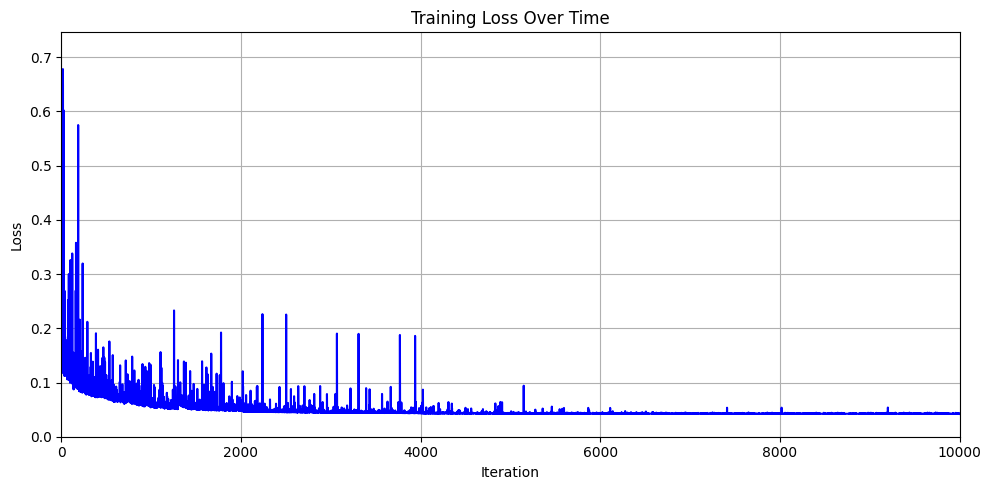

--- Visualizing Output at Iteration 10000 ---


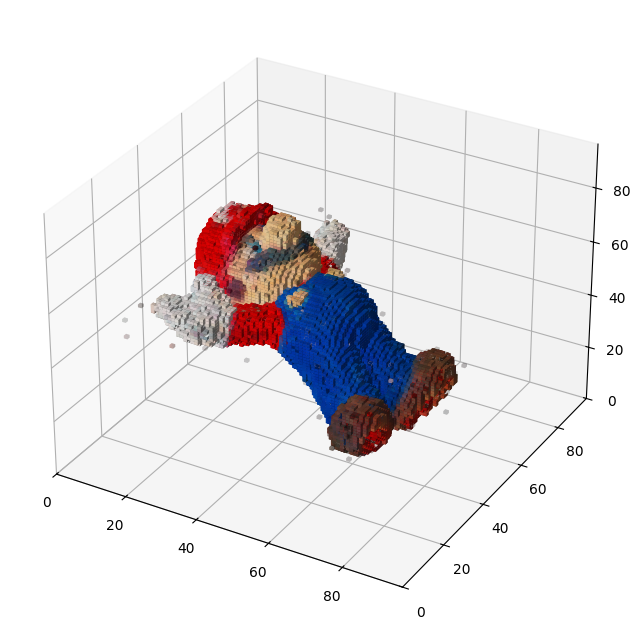

In [24]:
nca.train_morphogenesis(
    iterations=10000,
    lr=5e-4,
    batch_size=2,
    step_range=(32, 96),
    pool_size=1028,
    viz_log=100000,
    plot_log_interval=100 # Update plot every 10 iterations
)

,N_CHANNELS,LPPN_HIDDEN,Total Loss,Morphogenesis Loss,LPPN Loss
0,32,32,0.277236,0.244225,0.033012
1,32,64,0.262965,0.244225,0.018741
2,32,72,0.262725,0.244225,0.018500
3,32,96,0.259394,0.244225,0.015170
4,32,128,0.260180,0.244225,0.015956
5,40,32,1.793572,1.755775,0.037796
6,40,64,0.268387,0.244225,0.024162
7,40,72,0.196765,0.163951,0.032814
8,40,96,0.265517,0.244225,0.021292
9,40,128,0.257721,0.244225,0.013496


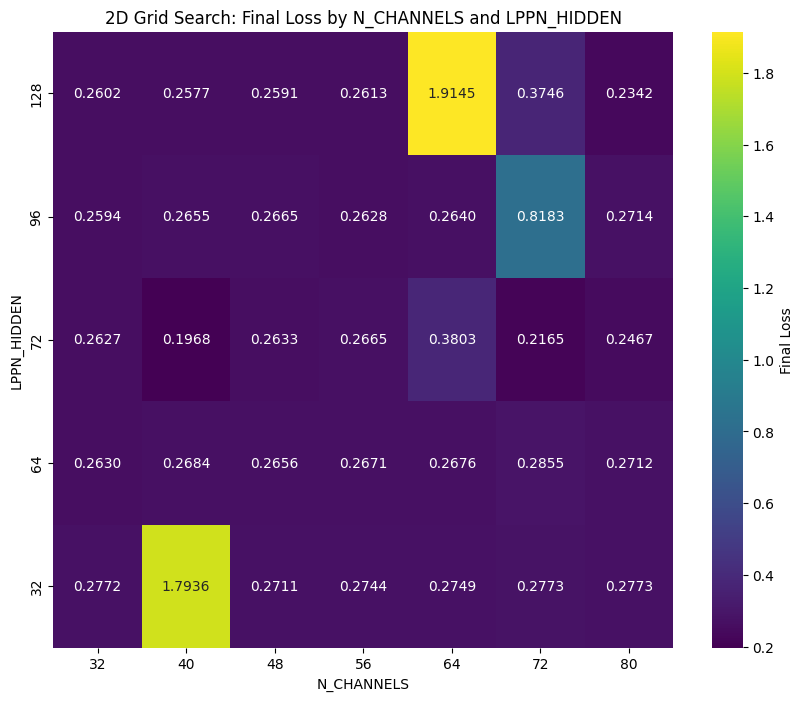

In [65]:
# 1. Define a sweep training loop to return final losses
def train_sweep(nca_model, iterations=1000, lr=1e-3, batch_size=2, step_range=(32, 96)):
    device = next(nca_model.parameters()).device
    optimizer = optim.Adam(nca_model.parameters(), lr=lr)
    pool = nca_model.create_seed(batch_size=batch_size, device=device)

    final_total, final_shape, final_rgba = 0, 0, 0

    for i in range(1, iterations + 1):
        steps = random.randint(step_range[0], step_range[1])
        current_state = pool.clone()
        current_state[0] = nca_model.create_seed(batch_size=1, device=device)[0]

        nca_model.train()
        optimizer.zero_grad()

        final_state = nca_model(current_state, steps)

        # Using the now-modified existing loss function
        total_loss, shape_loss, rgba_loss = nca_model.compute_morphology_loss(final_state)

        overflow_loss = torch.mean(torch.abs(final_state - torch.clamp(final_state, -1.0, 1.0)))
        loss_w_reg = total_loss + (100.0 * overflow_loss)

        loss_w_reg.backward()
        torch.nn.utils.clip_grad_norm_(nca_model.perception.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(nca_model.adaptation.parameters(), 1.0)

        optimizer.step()
        pool = final_state.detach()

        final_total = total_loss.item()
        final_shape = shape_loss.item()
        final_rgba = rgba_loss.item()

    return final_total, final_shape, final_rgba

# 2. Setup Sweep Parameters
n_channels_list = [32, 40, 48, 56, 64, 72, 80]
lppn_hidden_list = [32, 64, 72, 96, 128]

MARGIN_PROP = 0.25
COARSE_SIZE = 16
N_FREQS = 1
LPPN_LAYERS = 5

results = []

print("Starting Grid Sweep...")

# 3. Nested Loop structure
for channels in n_channels_list:
    for hidden in lppn_hidden_list:
        print(f"Testing N_CHANNELS={channels}, LPPN_HIDDEN={hidden}...")

        # Model Initialization
        model = NCA(
            channels=channels,
            coarse_size=COARSE_SIZE,
            lppn_hidden=hidden,
            harmonics=N_FREQS,
            num_sine_layers=LPPN_LAYERS
        ).to(DEVICE)

        # The .load() method now intrinsically updates the coarse_size with padding
        model.load("Big_mario.npy", margin_proportion=MARGIN_PROP, display_plots=False)

        # Train and track metrics
        final_tot, final_shape, final_lppn = train_sweep(model, iterations=1000, batch_size=2)

        results.append({
            'N_CHANNELS': channels,
            'LPPN_HIDDEN': hidden,
            'Total Loss': final_tot,
            'Morphogenesis Loss': final_shape,
            'LPPN Loss': final_lppn
        })

        # 4. VRAM Safety: Free up memory
        del model
        torch.cuda.empty_cache()
        gc.collect()

clear_output()
df_results = pd.DataFrame(results)
display(df_results)

# 5. Plotting / Visualization
pivot_df = df_results.pivot(index='LPPN_HIDDEN', columns='N_CHANNELS', values='Total Loss')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'Final Loss'})
plt.title('2D Grid Search: Final Loss by N_CHANNELS and LPPN_HIDDEN')
plt.xlabel('N_CHANNELS')
plt.ylabel('LPPN_HIDDEN')
plt.gca().invert_yaxis() # Invert y-axis so higher hidden dimensions are at the top
plt.show()

[SEED TEST] steps=512 render_size=(96, 96, 96) alive_cells=691
[SEED TEST] coarse living mask


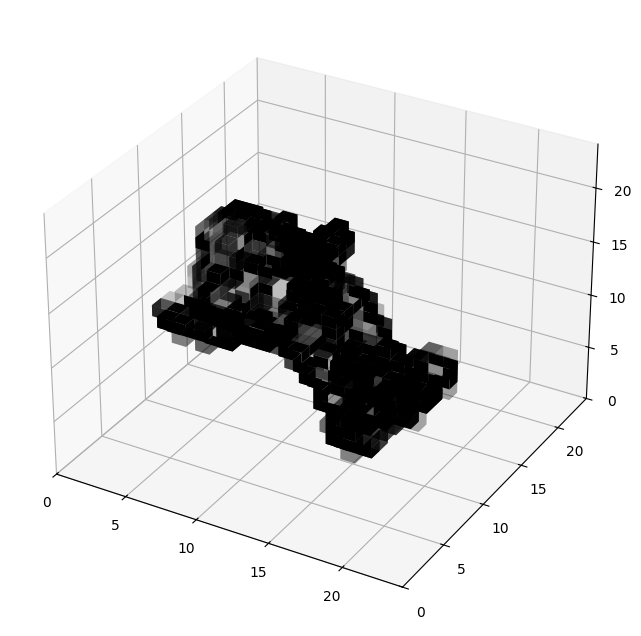

[SEED TEST] decoded output


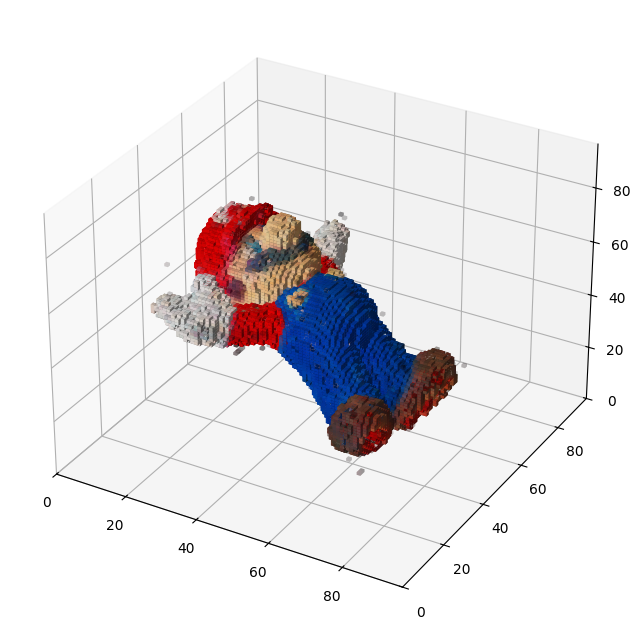

Native decoded shape: (4, 96, 96, 96)


In [25]:
seed_test_native = nca.test_seed_rollout(steps=512, render_size=nca.target_size, display=True)
print(f"Native decoded shape: {tuple(seed_test_native['decoded'].shape)}")

# seed_test_2x = nca.test_seed_rollout(steps=96, render_size=nca.target_size * 2, display=False)
# print(f"2x decoded shape: {tuple(seed_test_2x['decoded'].shape)}")
# nca.display_voxels(seed_test_2x['decoded'])


### SAVE

In [26]:
def export_nca_weights(nca, iterations=0, folder_path="./", json_filename="nca_weights.json", bin_filename="nca_weights.bin", manifest_filename="nca_manifest.json"):
    state_dict = nca.state_dict()
    sections = {'perception': {}, 'adaptation': {}, 'lppn': {}}

    # Ensure the folder exists
    folder = Path(folder_path)
    folder.mkdir(parents=True, exist_ok=True)

    json_path = folder / json_filename
    bin_path = folder / bin_filename
    manifest_path = folder / manifest_filename

    for name, tensor in state_dict.items():
        prefix, param_name = name.split('.', 1)
        if prefix not in sections:
            continue
        flat = tensor.detach().cpu().numpy().astype(np.float32).reshape(-1)
        sections[prefix][param_name] = {
            'shape': list(tensor.shape),
            'data': flat.tolist(),
        }

    weights = {
        'meta': {
            'channels': nca.channels,
            'coarse_size': nca.coarse_size,
            'target_size': nca.target_size,
            'scale': nca.scale,
        },
        **sections,
    }

    with open(json_path, 'w') as f:
        json.dump(weights, f)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
    ram_gb = psutil.virtual_memory().used / (1024 ** 3)

    manifest = {
        'meta': weights['meta'],
        'training_iterations': iterations,
        'gpu_used': gpu_name,
        'ram_used': f"{ram_gb:.2f} GB"
    }

    offset = 0
    total_bytes = 0

    with open(bin_path, 'wb') as f:
        for section in ['perception', 'adaptation', 'lppn']:
            manifest[section] = {}
            for name, entry in weights[section].items():
                data = np.array(entry['data'], dtype=np.float32)
                f.write(data.tobytes())
                manifest[section][name] = {
                    'offset': offset,
                    'shape': entry['shape'],
                    'count': int(data.size),
                }
                offset += data.nbytes
                total_bytes += data.nbytes

    with open(manifest_path, 'w') as f:
        json.dump(manifest, f, indent=2)

    print(f"JSON: {json_path.resolve()}")
    print(f"Binary: {total_bytes / 1e3:.1f} KB -> {bin_path.resolve()}")
    print(f"Manifest: {manifest_path.resolve()}")



In [27]:

# This cell will wait for your training to finish, then save and exit.
save_path = '/content/drive/MyDrive/NCA_Export3'
os.makedirs(save_path, exist_ok=True)

export_nca_weights(
    nca,
    iterations=nca.iterations,
    folder_path=save_path,
    json_filename="nca_mario_weights.json",
    bin_filename="nca_mario_weights.bin",
    manifest_filename="nca_mario_manifest.json"
)

print(f"Saved to {save_path}. Shutting down...")


JSON: /content/drive/MyDrive/NCA_Export3/nca_mario_weights.json
Binary: 321.9 KB -> /content/drive/MyDrive/NCA_Export3/nca_mario_weights.bin
Manifest: /content/drive/MyDrive/NCA_Export3/nca_mario_manifest.json
Saved to /content/drive/MyDrive/NCA_Export3. Shutting down...


In [28]:
time.sleep(10)
runtime.unassign()